# Neural Network - 1D-CNN excecution

This notebook trains neural network models based on the paper [incluir citas].

The model implemented is `1dcnn` → Conv1D block + 4 Dense layers + Batch Normalization + Dropout.

This program:
1. 
2. 
3. 
4. 
5. 

This notebook expects the files generated by the preprocessing notebook:

- `Dataset/train/preprocessed_train.csv`
- `Dataset/test/preprocessed_test.csv`


## Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


## 1. Load preprocessed datasets

In [57]:
train_df = pd.read_csv("../../Dataset/train/preprocessed_train.csv")
test_df = pd.read_csv("../../Dataset/test/preprocessed_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (3918, 12)
Test shape: (980, 12)


,alcohol,density,residual sugar,total sulfur dioxide,free sulfur dioxide,chlorides,citric acid,fixed acidity,pH,sulphates,volatile acidity,quality
0,0.811436,-1.015152,-0.396463,0.273654,0.090254,-0.876675,-0.777631,-1.476971,0.727373,-1.572934,-0.676949,7
1,1.954627,-1.633570,-0.945154,-0.762947,0.265528,-0.502390,-0.199185,-0.773832,0.465637,-0.870325,0.225769,7
2,-0.903350,0.248282,-0.376867,0.839073,1.492444,9.088661,-0.116550,-0.539453,-0.450439,-0.079891,-0.075137,5
3,0.893092,-1.477303,-1.023539,-0.998539,-0.201869,-0.455604,0.048721,-0.656643,-0.843043,2.203587,-0.576647,6
4,1.056405,-1.181394,-0.435656,-0.904302,0.090254,-0.783104,-1.438712,-1.828540,0.727373,-1.133804,0.225769,8


## 2. Separate attributes and labels

In [58]:
X_train = train_df.drop("quality", axis=1).astype("float32")
y_train = train_df["quality"].astype("int32")

X_test = test_df.drop("quality", axis=1).astype("float32")
y_test = test_df["quality"].astype("int32")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())


X_train: (3918, 11)
y_train: (3918,)
X_test: (980, 11)
y_test: (980,)

Training class distribution:
quality
3      16
4     130
5    1166
6    1758
7     704
8     140
9       4
Name: count, dtype: int64

Test class distribution:
quality
3      4
4     33
5    291
6    440
7    176
8     35
9      1
Name: count, dtype: int64


## 3. Encode labels

Wine quality labels are not always `0, 1, 2, ...`.

For neural networks, we encode them before training.

Example:

`3 → 0`, `4 → 1`, `5 → 2`, etc.


In [59]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train).astype("int32")
y_test_encoded = encoder.transform(y_test).astype("int32")

num_classes = len(encoder.classes_)
num_attributes = X_train.shape[1]

print("Classes on dataset:", encoder.classes_)
print("Number of classes:", num_classes)
print("Number of attributes:", num_attributes)

Classes on dataset: [3 4 5 6 7 8 9]
Number of classes: 7
Number of attributes: 11


## 4. Import model

In [60]:
sys.path.append(os.path.abspath("../../"))

from models.oneD_CNN_model import create_model 

model = create_model(num_classes=num_classes, num_attributes=num_attributes)

model.summary()

Model: "wine_quality_1d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_block (Conv1D)           │ (None, 11, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        45,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_128                  │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_128 (Activation)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_64                   │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_64 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_32                   │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_32 (Activation)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quality_output (Dense)          │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,191 (223.40 KB)

 Trainable params: 56,743 (221.65 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Compile model

In [83]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 6. Train model

In [84]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_encoded,
    epochs=100,
    batch_size=32,
    validation_split=.2,
    callbacks=[early_stopping]
)


Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5683 - loss: 1.0131 - val_accuracy: 0.5689 - val_loss: 1.0550
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5686 - loss: 1.0108 - val_accuracy: 0.5689 - val_loss: 1.0564
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5609 - loss: 0.9970 - val_accuracy: 0.5714 - val_loss: 1.0551
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5782 - loss: 0.9961 - val_accuracy: 0.5740 - val_loss: 1.0548
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5734 - loss: 0.9994 - val_accuracy: 0.5689 - val_loss: 1.0552
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5641 - loss: 1.0052 - val_accuracy: 0.5714 - val_loss: 1.0539
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5747 - loss: 1.0102 - val_accuracy: 0.5651 - val_loss: 1.0515
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5635 - loss: 0.9978 - val_accuracy: 0.5702 -

## 7. Training behavior plots

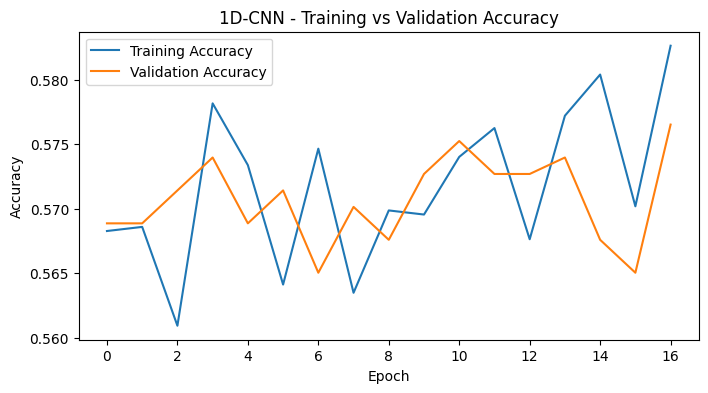

In [85]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("1D-CNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


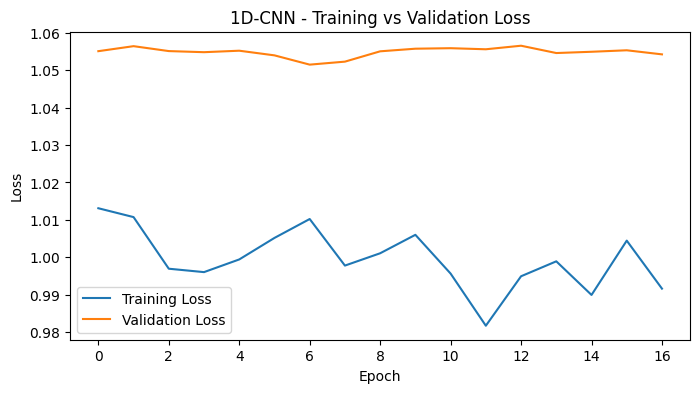

In [86]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("1D-CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 8. Predictions

In [87]:
y_train_pred_probs = model.predict(X_train)
y_test_pred_probs = model.predict(X_test)

print(y_test_pred_probs[:5])

y_train_pred = np.argmax(y_train_pred_probs, axis=1)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
[[8.35430063e-03 7.29733035e-02 6.41350687e-01 2.70691603e-01
  6.38434291e-03 2.17695677e-04 2.79691976e-05]
 [1.14088960e-03 5.83320251e-03 6.16506599e-02 5.38327992e-01
  3.30809504e-01 6.01027235e-02 2.13501882e-03]
 [6.88220514e-03 4.41031419e-02 5.07532716e-01 4.17728066e-01
  2.24390961e-02 1.19883812e-03 1.15940406e-04]
 [1.04883476e-03 5.76329650e-03 5.50928637e-02 5.29232621e-01
  3.43347996e-01 6.33526295e-02 2.16179388e-03]
 [3.18650506e-04 4.39865375e-03 1.16528124e-02 3.78997087e-01
  4.91806298e-01 1.10569425e-01 2.25713453e-03]]


## 9. Metrics

In [88]:
def evaluate_model(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"{dataset_name} Results")
    print("---------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return {
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


In [89]:
train_metrics = evaluate_model(y_train_encoded, y_train_pred, "Training")
print()
test_metrics = evaluate_model(y_test_encoded, y_test_pred, "Test")

Training Results
---------------------
Accuracy : 0.6090
Precision: 0.5633
Recall   : 0.6090
F1 Score : 0.5759

Test Results
---------------------
Accuracy : 0.5622
Precision: 0.5215
Recall   : 0.5622
F1 Score : 0.5303


## 10. Classification report

In [90]:
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=[str(label) for label in encoder.classes_],
        zero_division=0
    )
)


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        33
           5       0.59      0.58      0.59       291
           6       0.55      0.74      0.63       440
           7       0.55      0.32      0.41       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.56       980
   macro avg       0.24      0.23      0.23       980
weighted avg       0.52      0.56      0.53       980



## 11. Confusion matrix

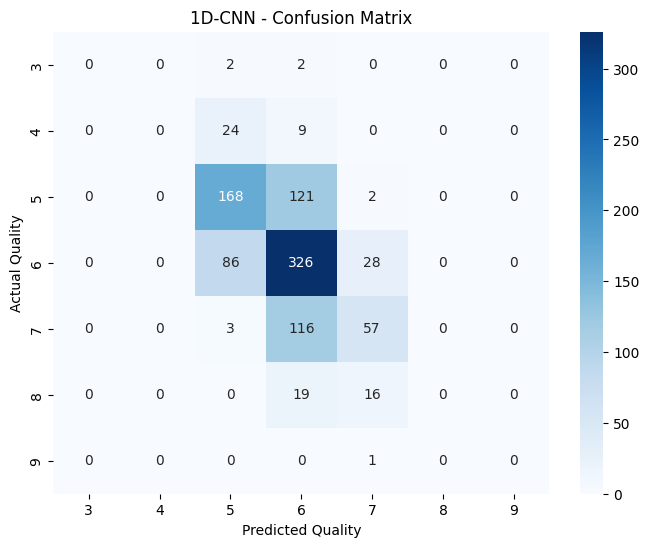

In [91]:
cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("1D-CNN - Confusion Matrix")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.show()
